# **<u>Fourier Series Assignment</u>**

In [33]:
import numpy             as np
import sympy             as sp
import matplotlib.pyplot as plt
from scipy import integrate 

### **Fourier Coefficient Caculation function :**

In [34]:
T = 10         # Time period
w0 = 2*np.pi/T # fundamental frequency

def real(t, func, n):
    return func(t)*np.cos(n*w0*t)/T

def imaginary(t, func, n) :
    return func(t)*np.sin(n*w0*t)/T

def FS_coeffs(func, n) :
    realans, err_real = integrate.quad(real, 0, T, args=(func, n))
    imagans, err_imag = integrate.quad(imaginary, 0, T, args=(func, n))
    
    return err_real, err_imag, realans - 1.0j*imagans

### **Reconstruction Function** :

In [35]:
def reconstruction(tvec, X) :
    recon = np.zeros_like(tvec, dtype=complex)
    count1 = 0

    for count in nvec :
        argmnt = count*w0*tvec
        recon  = recon + X[count1]*np.exp(1.0j*argmnt)
        count1 = count1 + 1

    plt.plot(tvec,recon.real, color='#7174F4')
    plt.title("Reconstructed Function")
    plt.xlabel("time")
    plt.grid()
    plt.show()

    return recon

---
### **Plotting function :**

In [36]:
def show_results(nvec, real_err, imag_err, X) :

    figure, axis = plt.subplots(2,2)

    axis[0,0].plot(nvec, real_err, color='black')
    axis[0,0].plot(nvec, imag_err, color='#7174F4')
    axis[0,0].set_title("Error Magnitude")
   
    axis[0,1].stem(nvec, np.real(X),linefmt='#7174F4',markerfmt='.' ,use_line_collection=True)
    axis[0,1].set_title("Real FC")

    axis[1,0].stem(nvec, np.imag(X),linefmt='#7174F4',markerfmt='.' ,use_line_collection=True)
    axis[1,0].set_title("Imaginary FC")

    axis[1,1].stem(nvec, np.abs(X),linefmt='#7174F4',markerfmt='.' ,use_line_collection=True)
    axis[1,1].set_title("Absolute FC")


---

In [37]:
T

10

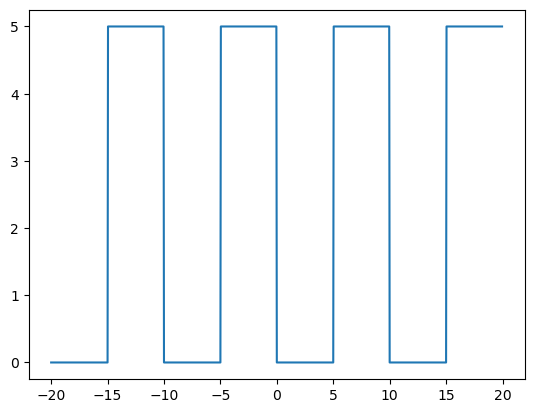

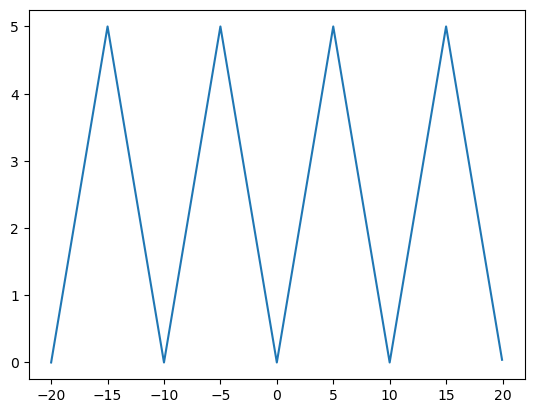

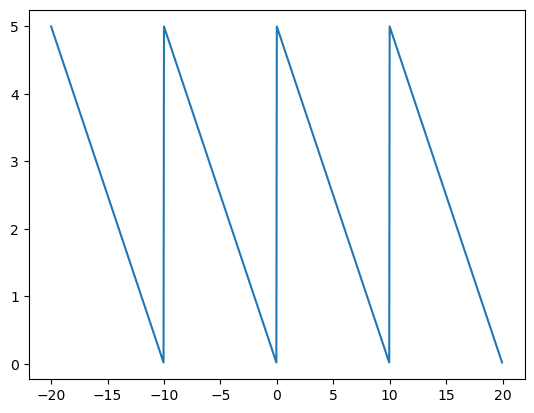

In [38]:
t = sp.symbols("t")
tvec = np.linspace(-20,20,1000,endpoint=False)

# SQUARE WAVE
x = sp.Piecewise((0, t%T <= T/2), (5, (t%T > T/2)))
xnum = sp.lambdify(t,x)

# TRIANGULAR WAVE
y = sp.Piecewise((t - (t//T)*T, t%T <= T/2), (T+(t//T)*T - t, t%T >= T/2))
ynum = sp.lambdify(t,y)

# SAWTOOTH WAVE
z = sp.Piecewise(((T+(t//T)*T - t)/2, t%T <= T))
znum = sp.lambdify(t,z)

plt.plot(tvec,xnum(tvec))
plt.show()
plt.plot(tvec,ynum(tvec))
plt.show()
plt.plot(tvec,znum(tvec))
plt.show()

In [39]:
FS_coeffs_vec = np.vectorize(FS_coeffs)

N=50
nvec = np.arange(-N,N,1)
errR, errI, X = FS_coeffs_vec(xnum, nvec)

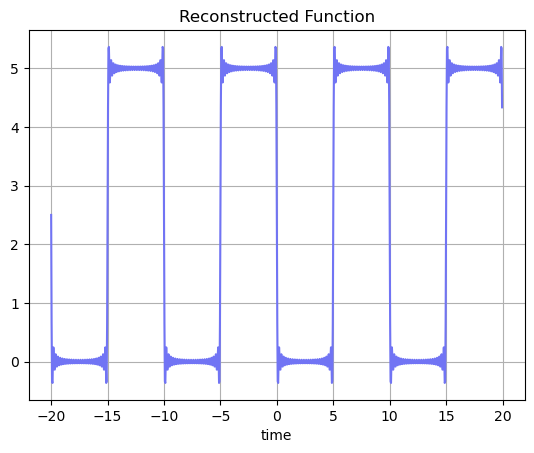

In [40]:
R = reconstruction(tvec, X)

/home/erased/anaconda3/lib/python3.9/site-packages/matplotlib/cbook/__init__.py:1298: ComplexWarning: Casting complex values to real discards the imaginary part
  return np.asarray(x, float)


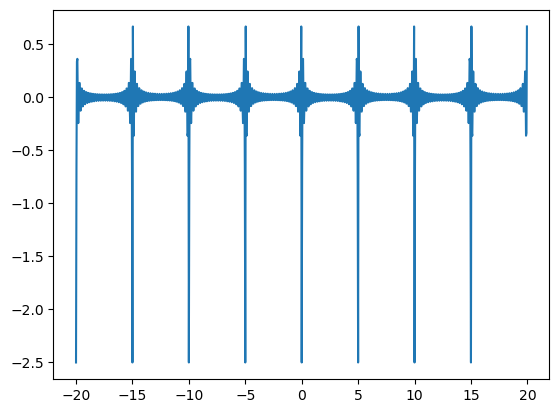

In [41]:
plt.plot(tvec, xnum(tvec) - R)

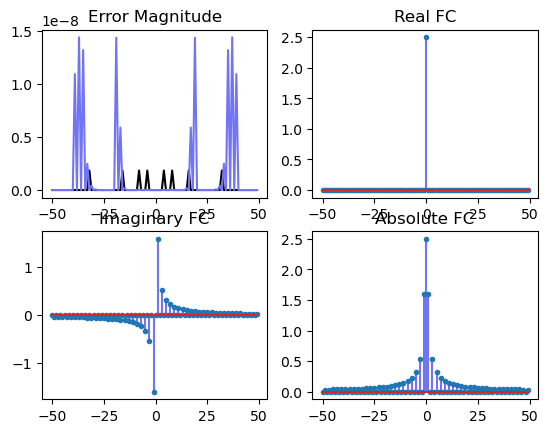

In [42]:
show_results(nvec, errR, errI, X)

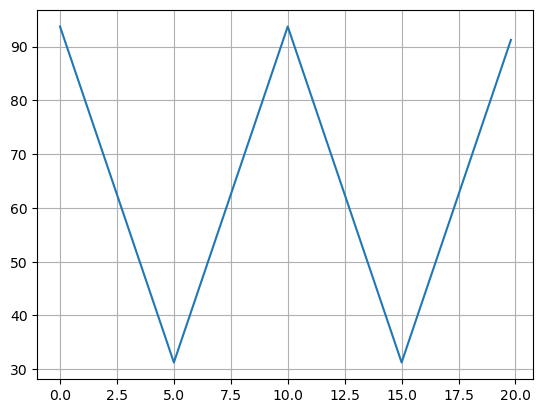

In [43]:
def time_convolution(t, x, y, k) :
    return x(t)*y(k-t)

xaxis = np.linspace(0,20,100,endpoint=False)
integral_values = []
for k in xaxis:
    integral_values.append(integrate.quad(time_convolution, 0, T, args=(xnum, znum, k))[0])

plt.plot(xaxis, integral_values)
plt.grid()
plt.show()

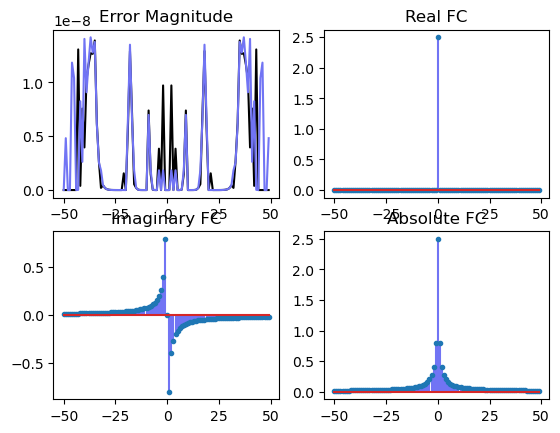

In [44]:
errI, errR, Z = FS_coeffs_vec( znum, nvec)
show_results(nvec, errR, errI, Z)

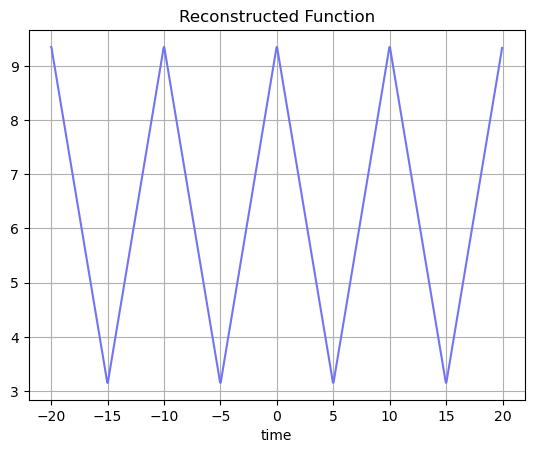

In [45]:
R = reconstruction(tvec, X*Z)

## **PARSEVAL'S THEOREM VERIFICATION :**

---
firstly for x -> square wave

In [46]:
integrate.quad(sp.lambdify(t, x*x), 0, T)[0]/T

12.5

In [47]:
errR, errI, X = FS_coeffs_vec(xnum, nvec)
sum(np.abs(X)**2)

12.449346159146527

/tmp/ipykernel_84025/1754420899.py:12: IntegrationWarning: The maximum number of subdivisions (50) has been achieved.
  If increasing the limit yields no improvement it is advised to analyze 
  the integrand in order to determine the difficulties.  If the position of a 
  local difficulty can be determined (singularity, discontinuity) one will 
  probably gain from splitting up the interval and calling the integrator 
  on the subranges.  Perhaps a special-purpose integrator should be used.
  imagans, err_imag = integrate.quad(imaginary, 0, T, args=(func, n))


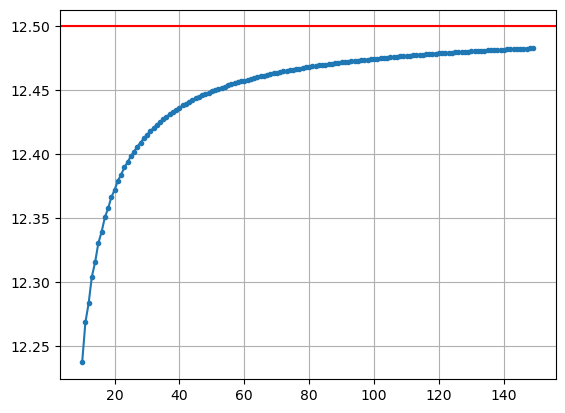

In [83]:
m = 150

index = np.arange(10,m,1)
results = []

nvec = np.arange(-m, m, 1)
X = FS_coeffs_vec(xnum, nvec)[2]
    
for N in index :
    results.append(sum(np.abs(X[m - 1 - N:m - 1 + N])**2))

plt.axhline(12.5,color='red')
plt.plot(index, results, marker='.')
plt.grid()
plt.show()

---
Now for y -> Triangular Wave

In [48]:
y2num = sp.lambdify(t, y*y)
integrate.quad(y2num, 0, T)[0]/T

8.333333333333332

In [49]:
Y = FS_coeffs_vec(ynum, nvec)[2]
sum(np.abs(Y)**2)

8.333330597925082

/tmp/ipykernel_84025/1754420899.py:11: IntegrationWarning: The maximum number of subdivisions (50) has been achieved.
  If increasing the limit yields no improvement it is advised to analyze 
  the integrand in order to determine the difficulties.  If the position of a 
  local difficulty can be determined (singularity, discontinuity) one will 
  probably gain from splitting up the interval and calling the integrator 
  on the subranges.  Perhaps a special-purpose integrator should be used.
  realans, err_real = integrate.quad(real, 0, T, args=(func, n))


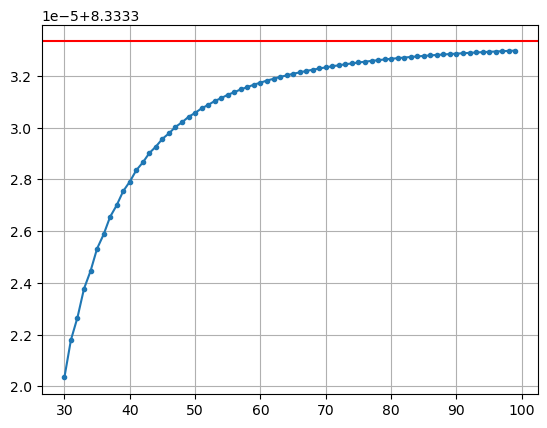

In [80]:
index = np.arange(30,100,1)
results = []

m = 100
nvec = np.arange(-m, m, 1)
Y = FS_coeffs_vec(ynum, nvec)[2]
    
for N in index :
    results.append(sum(np.abs(Y[m - 1 - N:m - 1 + N])**2))

plt.axhline(8.333333333,color='red')
plt.plot(index, results, marker='.')
plt.grid()
plt.show()

---
Now for z -> Sawtooth wave

In [50]:
z2num = sp.lambdify(t, z*z)
integrate.quad(z2num, 0, T)[0]/T

8.333333333333332

In [51]:
Z = FS_coeffs_vec(znum, nvec)[2]
sum(np.abs(Z)**2)

8.308001348871409

/tmp/ipykernel_84025/1754420899.py:11: IntegrationWarning: The maximum number of subdivisions (50) has been achieved.
  If increasing the limit yields no improvement it is advised to analyze 
  the integrand in order to determine the difficulties.  If the position of a 
  local difficulty can be determined (singularity, discontinuity) one will 
  probably gain from splitting up the interval and calling the integrator 
  on the subranges.  Perhaps a special-purpose integrator should be used.
  realans, err_real = integrate.quad(real, 0, T, args=(func, n))
/tmp/ipykernel_84025/1754420899.py:12: IntegrationWarning: The maximum number of subdivisions (50) has been achieved.
  If increasing the limit yields no improvement it is advised to analyze 
  the integrand in order to determine the difficulties.  If the position of a 
  local difficulty can be determined (singularity, discontinuity) one will 
  probably gain from splitting up the interval and calling the integrator 
  on the subrange

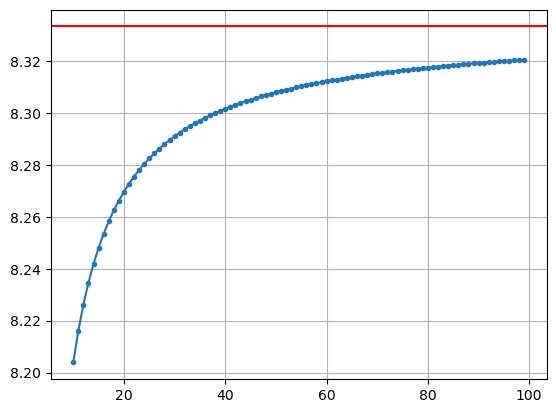

In [74]:
index = np.arange(10,100,1)
results = []

m = 100
nvec = np.arange(-m, m, 1)
Z = FS_coeffs_vec(znum, nvec)[2]
    
for N in index :
    results.append(sum(np.abs(Z[m - 1 - N:m - 1 + N])**2))

plt.axhline(8.333333333,color='red')
plt.plot(index, results, marker='.')
plt.grid()
plt.show()

## **Verifying Reiman - Lebesgue Lemma**

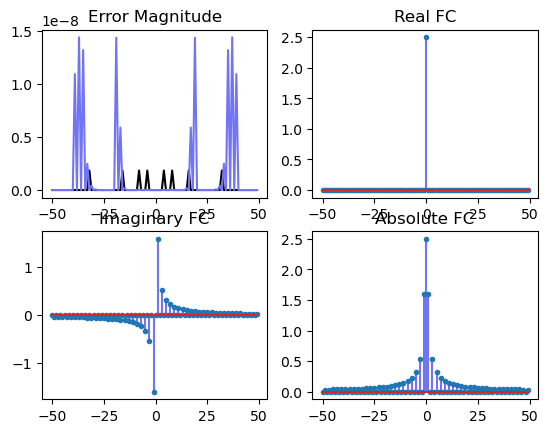

In [ ]:
errR, errI, X = FS_coeffs_vec(xnum, nvec)
show_results(nvec, errR, errI, X)

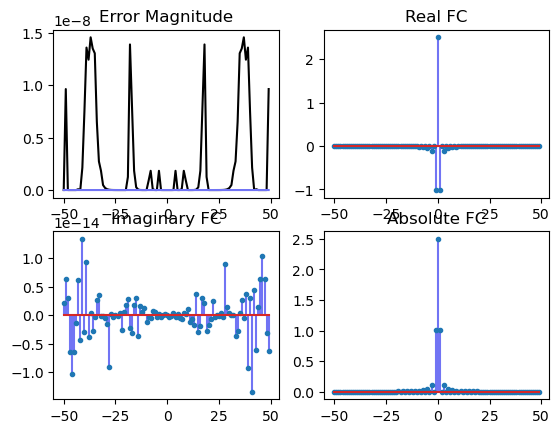

In [ ]:
errR, errI, Y = FS_coeffs_vec(ynum, nvec)
show_results(nvec, errR, errI, Y)

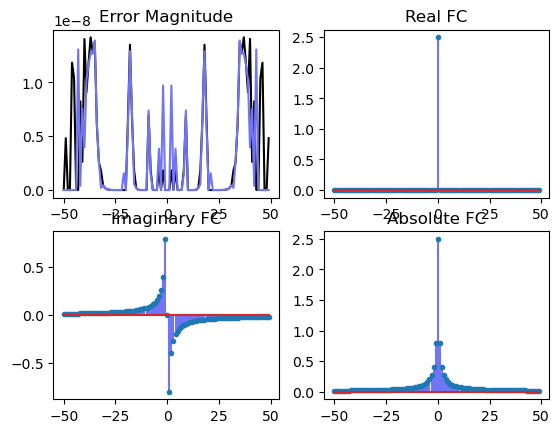

In [ ]:
errR, errI, Z = FS_coeffs_vec(znum, nvec)
show_results(nvec, errR, errI, Z)

### SINE WAVE :

0.0


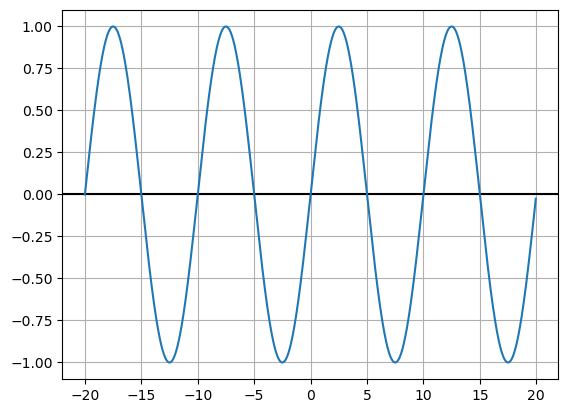

In [ ]:
sin = sp.lambdify(t, sp.sin(2*np.pi*t/T))
print(sin(0))
plt.axhline(0,color='black')
plt.plot(tvec, sin(tvec))
plt.grid()
plt.show()

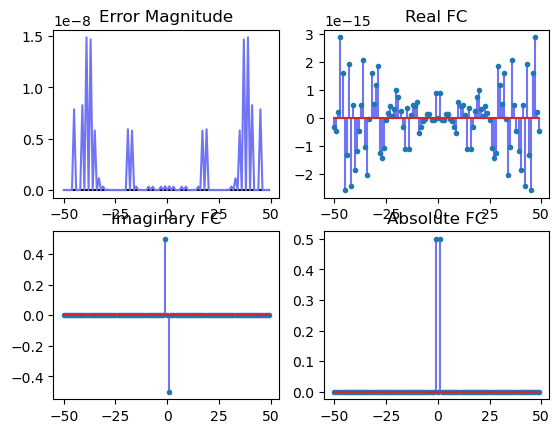

In [ ]:
errR, errI, sine = FS_coeffs_vec(sin,nvec)
show_results(nvec, errR, errI, sine)

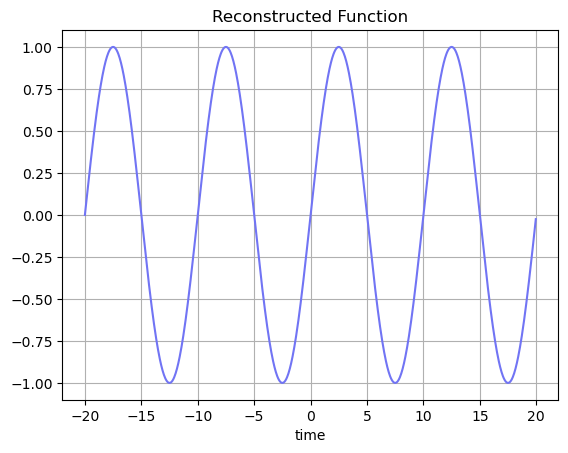

In [ ]:
R = reconstruction(tvec, sine)